## 유방암 데이터셋을 활용한 이진분류 다층 퍼셉트론 모델


In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [27]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [28]:
cancer.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [29]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [30]:
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['class'] = cancer.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [32]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [33]:
df['class'].value_counts()

class
1    357
0    212
Name: count, dtype: int64

In [34]:
import torch                        # Tensor 연산 + 자동미분 + GPU 지원
import torch.nn as nn               # 신경망 레이어
import torch.nn.functional as F     # 활성화, 손실함수
import torch.optim as optim         # 가중치 업데이트 알고리즘

torch.from_numpy() : numpy 배열을 pytorch 텐서로 변환  
df.values : DataFrame을 numpy 배열 형태로 변환  
float() : float32 형태로 변환

In [35]:
data = torch.from_numpy(df.values).float()  

data.shape

torch.Size([569, 31])

In [36]:
x = data[ : , : -1]
y = data[ : ,-1: ]

print(x.size(), y.size())

torch.Size([569, 30]) torch.Size([569, 1])


In [37]:
ratio = [.6 , .2, .2]   # 학습/ 검증/ 테스트 비율

In [38]:
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt

cnts = [train_cnt, valid_cnt, test_cnt]
print(f' 학습/ 검증/ 테스트 갯수 : {cnts}')

 학습/ 검증/ 테스트 갯수 : [341, 113, 115]


In [39]:
indices = torch.randperm(data.size(0))  # 0 ~ n-1개 (568) 까지 숫자를 무작위로 섞은 텐서

x= torch.index_select(x, dim=0, index=indices)  # 섞인 인덱스 순서대로 x를 재정렬
y= torch.index_select(y, dim=0, index=indices)  # 섞인 인덱스 순서대로 y를 재정렬

x = x.split(cnts, dim=0)        # x를 train / valid / test 개수 기준으로 분할
y = y.split(cnts, dim=0)        # y도 동일

for x_i , y_i in zip(x,y):
    print(x_i.size(), y_i.size())
    

torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])


### 3. 전처리

In [40]:
scaler = StandardScaler()
scaler.fit(x[0].numpy())    # 학습데이터 기준으로 스케일 기준 학습

x = [
    torch.from_numpy(scaler.transform(x[0].numpy())).float(),   # train 데이터 정규화 (FloatTensor형태로 최종변환)
    torch.from_numpy(scaler.transform(x[1].numpy())).float(),   # valid 데이터 정규화 (FloatTensor형태로 최종변환)
    torch.from_numpy(scaler.transform(x[2].numpy())).float()    # test 데이터 정규화 (FloatTensor형태로 최종변환)
]

df = pd.DataFrame(x[0].numpy(), columns=cancer.feature_names)   # 스케일링된 데이터 데이터프레임 변환
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.002637,0.648176,0.145472,-0.062661,0.618480,1.834345,1.558897,0.929861,0.499441,1.522211,...,0.261328,0.622817,0.327944,0.115064,1.378301,2.277688,1.941100,0.930994,-0.067022,1.578932
1,0.487963,0.900467,0.398361,0.360528,-0.963642,-0.685637,-0.683578,-0.403785,-1.002324,-0.767253,...,0.573215,1.336807,0.466996,0.451047,-0.591689,-0.592274,-0.561284,-0.222025,0.099705,0.064713
2,-0.678944,-0.453573,-0.706215,-0.665865,0.327546,-0.893647,-0.801100,-0.846666,-0.324567,-0.648115,...,-0.785136,0.127761,-0.841570,-0.713869,0.159396,-0.929018,-0.826364,-1.052052,0.503694,-0.925759
3,-0.667857,-0.437371,-0.695342,-0.655292,-0.848654,-0.878615,-0.759483,-0.664759,0.235473,-0.741416,...,-0.684593,0.008490,-0.700151,-0.663956,0.215191,-0.465766,-0.626787,-0.344281,0.344984,-0.698204
4,-0.010952,0.872692,0.062921,-0.162267,0.798581,2.595356,1.367583,0.420673,2.051144,1.881061,...,-0.134687,1.875976,-0.047791,-0.232558,0.919065,4.160030,2.658422,0.911960,3.655456,3.236758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,-0.412856,0.476896,-0.434400,-0.447454,-0.587507,-0.698415,-0.706809,-0.518634,-0.410179,0.079634,...,-0.543013,-0.359125,-0.561395,-0.555137,-1.631191,-0.991477,-0.992044,-0.983676,-1.133106,-0.770008
337,-0.551443,-0.330899,-0.579770,-0.562363,-0.631839,-0.712507,-0.694510,-0.571429,0.560082,-0.910793,...,-0.471197,0.519884,-0.562579,-0.500992,-0.338466,-0.443153,-0.598845,-0.286886,0.912493,-0.756809
338,-0.432258,-1.661794,-0.480307,-0.481955,-0.562570,-0.850053,-0.800230,-0.634233,-0.806131,0.062408,...,-0.563532,-1.434196,-0.588614,-0.577359,-0.020864,-0.558050,-0.799704,-0.478397,-0.177638,0.599019
339,0.138723,-1.066942,0.083056,0.001332,-0.500227,-0.476876,-0.520961,-0.352491,-1.027293,-0.458642,...,0.179252,-1.269177,0.182975,-0.023738,-0.424304,-0.312367,-0.244306,0.149138,0.357809,-0.075199


### 4. 모델 & 옵티마이저 구성
- 입력 특성 x[0].size(-1) => 30
- 은닉층 25 -> 20 -> 15 -> 10 -> 5 노드로 점차 축소하는 방식
- 각 은닉층 사이사이에 LeakyReLU 함수 적용
- 출력층 y[0].size(-1) => 1개 노드
- 출력층 활성화 함수 Sigmoid => 0 ~ 1 이진 분류 확률값 출력

In [41]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25),       # 입력 특성수 -> 은닉층 25개 노드
    nn.LeakyReLU(),                     # 음수 영역도 기울기 어느정도 유지하는 활성화 함수
    
    nn.Linear(25, 20),                  # 은닉층 25개 노드 -> 은닉층 20개 노드
    nn.LeakyReLU(),
    
    nn.Linear(20, 15),                  # ...
    nn.LeakyReLU(),
        
    nn.Linear(15, 10),                  # ...
    nn.LeakyReLU(),
        
    nn.Linear(10, 5),
    nn.LeakyReLU(),
    
    nn.Linear(5, y[0].size(-1)),        # 은닉층 5개 노드 -> 이진 분류는 1개
    nn.Sigmoid()                        # 출력값을 0 ~ 1 사이 확률로 변환
)

In [42]:
optimizer = optim.Adam(model.parameters())

## 5. 학습

In [43]:
n_epochs = 10000        # 학습 반복 횟수
batch_size = 32         # 한번에 학습할 샘플 수 (미니배치 크기)
print_interval = 100    # loss 출력 시기
early_stop = 1000       # 성능 개선 없을경우 학습을 중단할 최대 대기 에폭 수

In [44]:
# 모델 저장 설정
from copy import deepcopy   # 객체 완전 복사(best_model 저장둉)

lowest_loss = np.inf        # 최소 손실값(매우 큰 값 초기화)
best_model = None           # 최고 성능 모델 저장

lowest_epoch = np.inf       # 최소 손실이 나온 epoch 기록

In [ ]:
train_history, valid_history = [], []

for i in range(n_epochs):
    
    # 미니 배치 학습 준비
    indices = torch.randperm(x[0].size(0))  # 0 ~ n-1개 까지 숫자를 무작위로 섞은 텐서

    x_ = torch.index_select(x[0], dim=0, index=indices)  # 섞인 인덱스 순서대로 x를 재정렬 (dim=0 : 행을기준)
    y_ = torch.index_select(y[0], dim=0, index=indices)  # 섞인 인덱스 순서대로 y를 재정렬

    x_ = x_.split(batch_size, dim=0)        # 배치 크기 단위로 분할
    y_ = y_.split(batch_size, dim=0)        # y도 동일하게 처리
    
    train_loss, valid_los = 0, 0        # epoch 별 손실 초기화
    y_hat = []                          # 검증 예측값 저장
    
    # 미니배치 단위로 학습
    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)    # 순전파 진행 (예측)
        loss = F.binary_cross_entropy(y_hat_i, y_i)     # 이진분류의 손실 계산
    
        optimizer.zero_grad()   # 이전 기울기값 초기화
        loss.backward()         # 역전파 : 기울기 재계산
        
        optimizer.step()        # 가중치 업데이트
        train_loss += float(loss)   # Tensor -> float 형태로 epoch별 train_loss 총합
        
    train_loss = train_loss / len(x_)   # 평균 학습 손실
    
    
    # 검증단계(기울기 계산 하지 않음)
    with torch.no_grad():
        x_ = x[1].split(batch_size, dim=0)  # 검증 데이터도 배치 분할
        y_ = y[1].split(batch_size, dim=0)  
        
        valid_loss = 0
        
        
        # 배치 단위로 검증 데이터 순회
        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)        # 순전파(예측)
            loss = F.binary_cross_entropy(y_hat_i, y_i) # 검증 손실 계산
            
            valid_loss += float(loss)   # epoch별 valid_loss 총합
            
            y_hat += [y_hat_i]          # 예측값 저장
            
    valid_loss = valid_loss /len(x_)    # 평균 검증 손실

    
        # 시각화용 기록
    train_history += [train_loss]   # epoch 별 학습 손실
    valid_history += [valid_loss]   # epoch 별 검증 손실
    
        # 로그 확인용
    if (i + 1) % print_interval == 0 :  # 100번 마다 한번씩
        print(f"Epoch {i+1} : train_loss = {train_loss}, valid_loss = {valid_loss}, lowest_loss = {lowest_loss}")

    # 최저 손실갑 생신 시
    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss    # 최소 손실값 갱신
        lowest_epoch = i            # 해당 epoch를 최소 손실 epoch로 저장

        best_model = deepcopy(model.state_dict())   # 최적 모델은 가중치 저장
    else:
        # 현재 epoch -> 마지막으로 성능이 좋아진 epoch이 early stop 기준보다 커지면
        if early_stop > 0 and (i + 1) - lowest_epoch >=  early_stop:
            print(f'{early_stop} epoch 동안 향상된 기록이 없습니다.')
            break
print(f'최고 검증 성능의 에포크는 {lowest_epoch + 1}, 그 때의 최저 손실 : {lowest_loss:.4e}')

model.load_state_dict(best_model)

Epoch 100 : train_loss = 0.00013467254815292438, valid_loss = 0.9117427153869357, lowest_loss = 0.07519904407672584
Epoch 200 : train_loss = 1.3311909692781398e-05, valid_loss = 0.926494268472652, lowest_loss = 0.07519904407672584
Epoch 300 : train_loss = 4.859553278353896e-06, valid_loss = 1.5817253861453082, lowest_loss = 0.07519904407672584
Epoch 400 : train_loss = 1.950358661401646e-06, valid_loss = 1.5799501831276075, lowest_loss = 0.07519904407672584
Epoch 500 : train_loss = 9.34566239428866e-07, valid_loss = 1.5780237722923403, lowest_loss = 0.07519904407672584
Epoch 600 : train_loss = 4.79422059708089e-07, valid_loss = 1.5760444812100616, lowest_loss = 0.07519904407672584
Epoch 700 : train_loss = 2.4406312638169643e-07, valid_loss = 1.5739859748669431, lowest_loss = 0.07519904407672584
Epoch 800 : train_loss = 1.2773992125802154e-07, valid_loss = 1.5722258297047205, lowest_loss = 0.07519904407672584
Epoch 900 : train_loss = 7.73988500362283e-08, valid_loss = 1.5705243027252749,

<All keys matched successfully>

valid_loss += float(loss)   # Tensor -> float (메모리 누수 방지)

loss 는 Tensor. autograd 그래프를 가지고 있음
train_loss 또는 valid_loss가 더해질 때마다 이전 loss 연산 그래프를 함께 참조 => CPU/GPU 메모리 공간을 차지한다.  

그래서 python float 형태로 바꿔 숫자만 실수형으로 가져와서 저장하면 계산 그래프를 그리지 않음

6. 손실 기록 또는 손실 변화 이력 그래프

In [53]:
# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

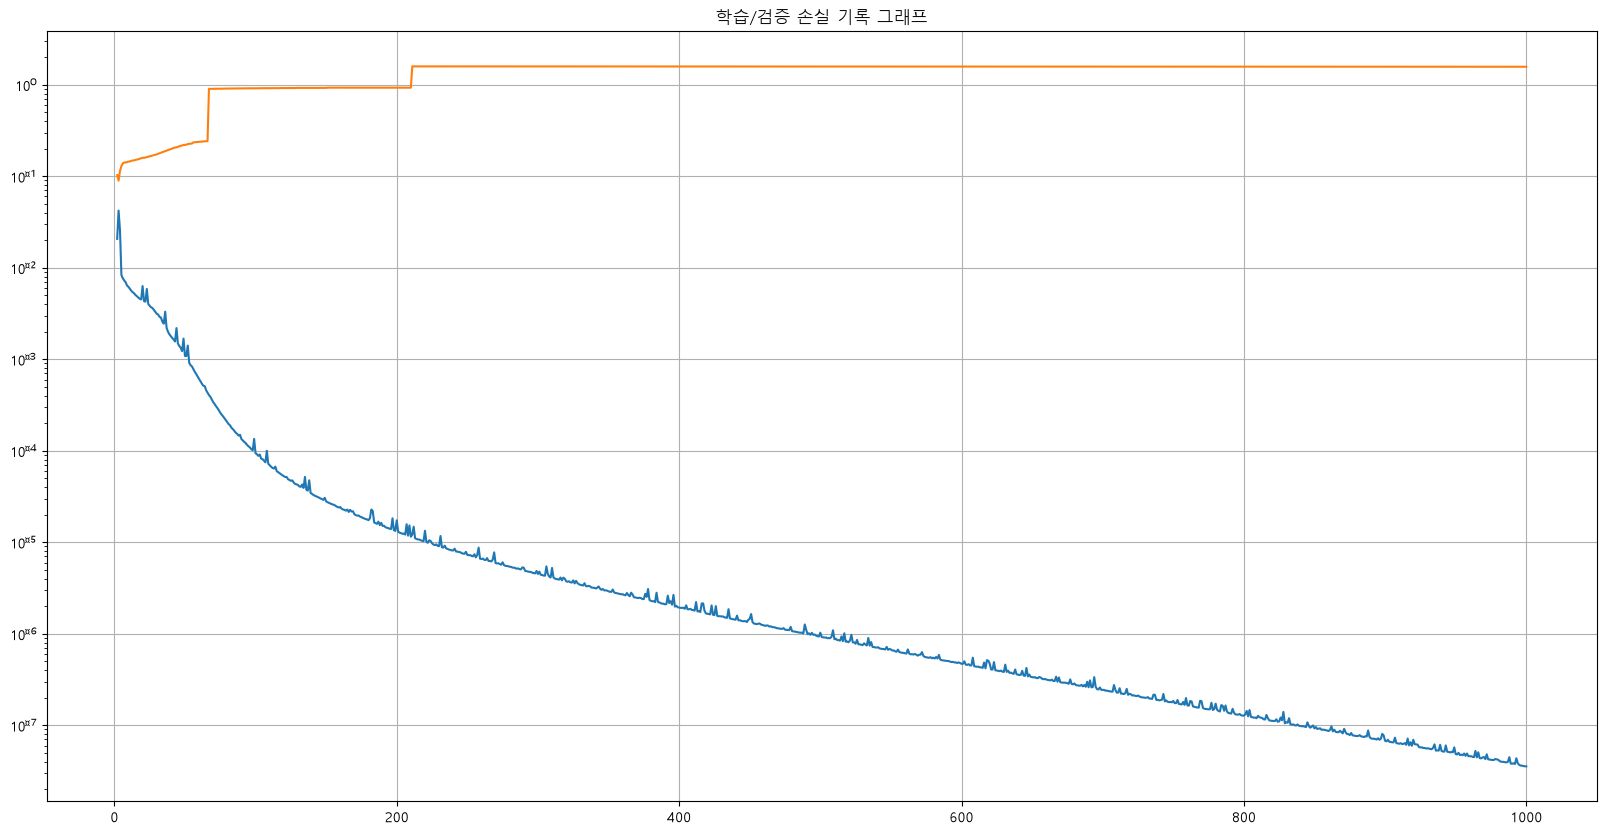

In [ ]:
plot_from = 2   # 0번 , 1번 초반 에폭은 불안정 하므로 3번째부터 사용하기 위한 설정

plt.figure(figsize= (20, 10))
plt.grid(True)
plt.title('학습/검증 손실 기록 그래프')

# 학습/ 검증 손실 곡선
plt.plot(
    range(plot_from, len(train_history)), train_history[plot_from:],    # 학습 그래프
    range(plot_from, len(valid_history)), valid_history[plot_from:]     # 검증 그래프
)
plt.yscale('log')
plt.show()

In [55]:
test_loss = 0
y_hat = []

with torch.no_grad():
    x_ = x[2].split(batch_size, dim=0)  # 테스트 데이터도 배치 분할
    y_ = y[2].split(batch_size, dim=0)  
    
    
    # 배치 단위로 테스트 데이터 순회
    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)        # 순전파(예측)
        loss = F.binary_cross_entropy(y_hat_i, y_i) # 테스스 손실 계산
        
        test_loss += float(loss)   # epoch별 valid_loss 총합
        
        y_hat += [y_hat_i]          # 예측값 저장
        
test_loss = test_loss /len(x_)    # 평균테스트 손실
y_hat = torch.cat(y_hat, dim=0)   # 배치별 예측 결과를 하나의 tensor로 결합
    
print(f'Test_loss : {round(test_loss,4)}')    

Test_loss : 0.1915


In [59]:
correct_cnt = (y[2] == (y_hat > .5)).sum()
total_cnt = float(y[2].size(0))

print(f'테스트 정확도는? {correct_cnt/total_cnt*100:.2f}%')

테스트 정확도는? 96.52%


y_hat > .5 : 예측 확률이 0.5 보다 크면 True, 아니면 False  
y[2] == : True = 1, False = 0 각각 맞는지 True, False 반환

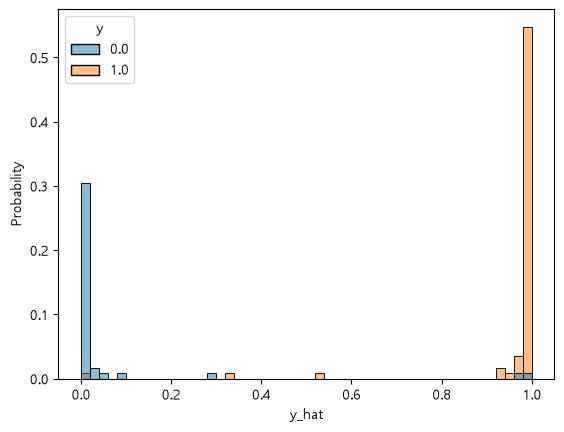

In [ ]:
# 시각화
df = pd.DataFrame(
    torch.cat([y[2], y_hat], dim=1)     # 실제값과 예측값을 열 방향으로 합침
    .detach()                           # autograd 그래프에서 분리
    .numpy(),                           # numpy 배열 형태로 반환
    columns= ['y','y_hat']
)

sns.histplot(
    df,
    x= 'y_hat',         # x축 : 모델 예측값
    hue= 'y',           # 색상 구분 : 실제 데이터
    bins= 50, 
    stat= 'probability' # 빈도를 확률(비율) 로 정규화
)
plt.show()

확신을 가지고 선택한 결과가 많아 모델 학습이 잘 된것으로 보임


In [62]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df.values[:, 0],     # 실제값 (0 또는 1)
    df.values[:, 1]     # 예측값 (0~ 1 사이 확률값, 시그모이드)
)

0.9892367906066536

ROC 기준 1.0 -> 완벽한 분류
         0.5 -> 랜덤 추측 수준